Aluna: Stefane Moraes

DRE: 116043651

### **Objetivo: fazer inferência bayesiana em um modelo $X \sim \text{B}( \alpha, \beta)$**

Para isto, considere uma amostra aleatória $(x_1, x_2, \dots, x_n)$ de tamanho $n = 105$, de uma variável aleatória $X$ com distribuição beta com parâmetros $\alpha$ e $\beta$. Ademais, para completar o modelo bayesiano, considere que $\alpha$ e $\beta$ são independentes a priori com $\alpha \sim \mathcal{G}(0.01; \, 0,01)$ e $\beta \sim \mathcal{G}(0.01; \, 0,01)$.

Deseja-se obter as estimativas, sob perda 0-1 (máximo a posteriori) dos parâmetros $\alpha$ e $\beta$, e construir intervalos de credibilidade (IC) de 95\% para estes parâmetros utilizando teoria bayesiana assintótica.


In [ ]:
# Dados
dados <- c(0.8357265, 0.6180437, 0.7705806, 0.8984286, 0.7397497, 0.8334146, 0.7216970,
           0.9494705, 0.7656284, 0.3598159, 0.4630324, 0.8216703, 0.8369436, 0.6542007,
           0.8220842, 0.8309679, 0.7463471, 0.7815482, 0.8815368, 0.4266183, 0.7743531,
           0.8353820, 0.8769271, 0.3129719, 0.6621014, 0.6168018, 0.7132438, 0.8849829,
           0.7568803, 0.7227289, 0.9361133, 0.8475986, 0.7036460, 0.6522368, 0.5092351,
           0.7883315, 0.6573478, 0.7395570, 0.7298979, 0.6617563, 0.5069975, 0.6518956,
           0.9573440, 0.7290825, 0.5372773, 0.8851941, 0.5175503, 0.6481358, 0.7976086,
           0.7202671, 0.6242151, 0.4793419, 0.7247397, 0.8075992, 0.7903313, 0.9158949,
           0.4611388, 0.6408313, 0.9143071, 0.4941746, 0.4899187, 0.4715561, 0.6815851,
           0.7869580, 0.9802524, 0.9326102, 0.8074523, 0.5831285, 0.7340206, 0.4431193,
           0.5849601, 0.6692145, 0.5500876, 0.8590751, 0.6558163, 0.6494348, 0.5934560,
           0.8857075, 0.5186138, 0.6906521, 0.4463526, 0.6527518, 0.5512945, 0.5770207,
           0.2771369, 0.7614698, 0.5706954, 0.9771544, 0.7343859, 0.4739817, 0.9907993,
           0.6073941, 0.7381598, 0.7224089, 0.5836280, 0.7243937, 0.4999090, 0.9135115,
           0.5822143, 0.8796882, 0.6840866, 0.6040923, 0.5201644, 0.5403177, 0.5409024)

# Parâmetros
a_priori <- 0.01
b_priori <- 0.01
n <- length(dados)

# Funções digama e trigama
digama <- function(x) { digamma(x) }
trigama <- function(x) { trigamma(x) }

- **Modelo (Verossimilhança):**

  $f(x) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1}(1-x)^{\beta-1} \mathbb{I}_{[0,1]}(x), \quad \alpha > 0 \quad \text{e} \quad \beta > 0.$

- **Prioris:**

  $f(\alpha) = \frac{b^a}{\Gamma(a)} \alpha^{a-1} \exp\{-b\alpha\} \mathbb{I}_{[0,\infty)}(\alpha), \quad a > 0 \quad \text{e} \quad b > 0.$

  $f(\beta) = \frac{b^a}{\Gamma(a)} \beta^{a-1} \exp\{-b\beta\} \mathbb{I}_{[0,\infty)}(\beta), \quad a > 0 \quad \text{e} \quad b > 0.$
    

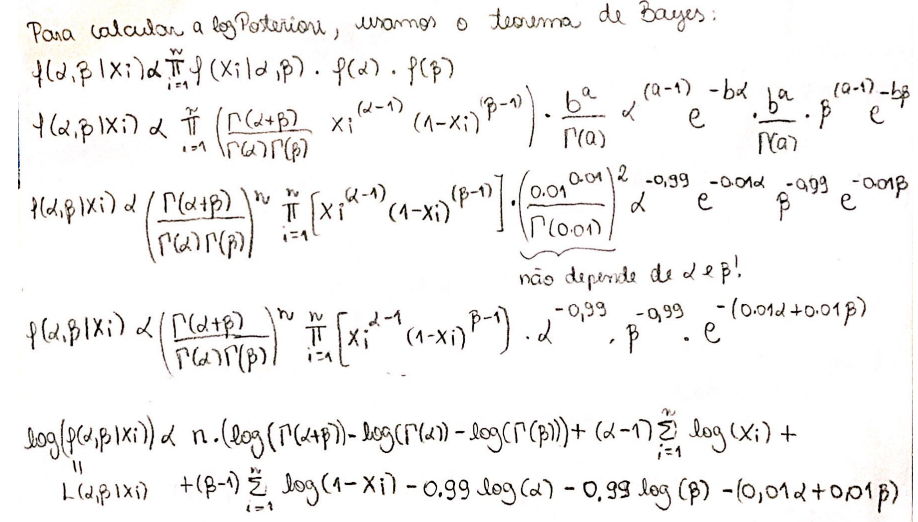

Vamos calcular as estimativas dos parâmetros $\alpha$ e $\beta$ pelo Método de Newton-Raphson, então para isso calcularemos a primeira e segunda derivadas da Log-Posteriori em relação a cada um dos parâmetros:

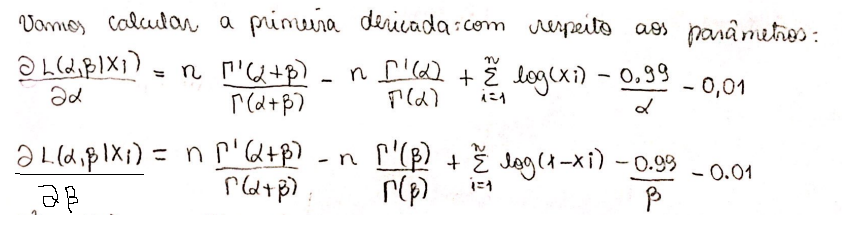

In [ ]:
# Primeira Derivada
gradiente <- function(alpha, beta, dados, n, soma_log, soma_log_compl) {
  g_alpha <- n * (digama(alpha + beta) - digama(alpha)) + soma_log - 0.99 / alpha - 0.01
  g_beta <- n * (digama(alpha + beta) - digama(beta)) + soma_log_compl - 0.99 / beta - 0.01
  return(c(g_alpha, g_beta))
}

Calculando as segundas derivadas:

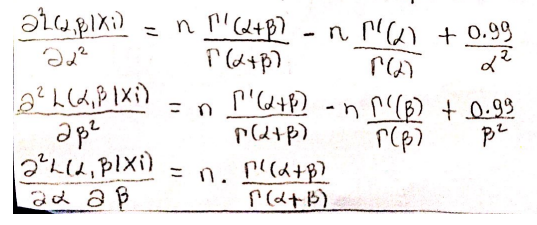

In [ ]:
# Segunda Derivada
hessiana <- function(alpha, beta, n) {
  h_alpha_alpha <- n * (trigama(alpha + beta) - trigama(alpha)) + 0.99 / alpha^2
  h_beta_beta <- n * (trigama(alpha + beta) - trigama(beta)) + 0.99 / beta^2
  h_alpha_beta <- n * trigama(alpha + beta)
  return(matrix(c(h_alpha_alpha, h_alpha_beta, h_alpha_beta, h_beta_beta), nrow = 2))
}

Aplicando o Método de Newton-Raphson:

In [ ]:
# Dados auxiliares
n <- length(dados)
soma_log <- sum(log(dados))
soma_log_compl <- sum(log(1 - dados))

# Método Newton-Raphson
alpha <- 1
beta <- 1
tol <- 1e-6
iter <- 0
max_iter <- 100

while (iter < max_iter) {
  grad <- gradiente(alpha, beta, dados, n, soma_log, soma_log_compl)
  hess <- hessiana(alpha, beta, n)
  delta <- solve(hess, grad)
  alpha <- alpha - delta[1]
  beta <- beta - delta[2]
  if (max(abs(delta)) < tol) break
  iter <- iter + 1
}

cat("Valores MAP após a convergência do método:\n")
cat("Valor estimado para alpha:", alpha, "\nValor estimado para beta:", beta, "\nNúmero de iterações:", iter,"\n")

Valores MAP após a convergência do método:
Valor estimado para alpha: 4.515708 
Valor estimado para beta: 1.979233 
Número de iterações: 7 


Supondo algumas condições, temos:

$IC(\alpha, 95\%) = \left(\hat{\alpha} - 1,96 \cdot \sqrt{\text{Var}(\hat{\alpha})} , \hat{\alpha} + 1,96 \cdot \sqrt{\text{Var}(\hat{\alpha})}\right)$

$IC(\beta, 95\%) = \left(\hat{\beta} - 1,96 \cdot \sqrt{\text{Var}(\hat{\beta})}, \hat{\beta} + 1,96 \cdot \sqrt{\text{Var}(\hat{\beta})}\right)$

$\text{Var}(\hat{\alpha}) = H_{11}^{-1}(\hat{\alpha}, \hat{\beta})$

$\text{Var}(\hat{\beta}) = H_{22}^{-1}(\hat{\alpha}, \hat{\beta})$

In [ ]:
# Cálculo da matriz de covariância e intervalos de credibilidade após a convergência do algoritmo de Newton-Raphson
if (iter < max_iter) {
  hess <- hessiana(alpha, beta, n)   # recalculamos a Hessiana no ponto estimado

  # Matriz de covariância (inversa da Hessiana negativa)!!!
  cov_matrix <- solve(-hess)

  # Erros padrão
  se_alpha <- sqrt(cov_matrix[1, 1])
  se_beta <- sqrt(cov_matrix[2, 2])

  # Intervalos de confiança de 95%
  ci_alpha <- c("(",alpha - 1.96 * se_alpha,",",alpha + 1.96 * se_alpha,")")
  ci_beta <- c("(",beta - 1.96 * se_beta,",", beta + 1.96 * se_beta,")")

  # Resultados
  cat("Intervalo de credibilidade para alpha (95%):",ci_alpha,"\n")
  cat("Intervalo de credibilidade para beta (95%):", ci_beta, "\n")
} else {
  cat("O algoritmo de Newton-Raphson não convergiu em", max_iter, "iterações.\n")
}

Intervalo de credibilidade para alpha (95%): ( 3.27379123723167 , 5.75762489413697 ) 
Intervalo de credibilidade para beta (95%): ( 1.47188361170989 , 2.48658317802822 ) 
